In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI: 869487060177069
V1.0.0.8
V10.1

In [65]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V4C-934.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 92347 entries, 0 to 92346
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  92347 non-null  str  
 1   Message  92347 non-null  str  
 2   Status   92347 non-null  str  
dtypes: str(3)
memory usage: 2.1 MB


In [66]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252523    82606
0x252514     5883
0x252513     3544
0x252501      193
0x252511      121
Name: count, dtype: int64

In [67]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 92347 entries, 0 to 92346
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  92347 non-null  str  
 1   Message  92347 non-null  str  
 2   Status   92347 non-null  str  
 3   Headers  92347 non-null  str  
dtypes: str(4)
memory usage: 2.8 MB


Odometer

In [68]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 9427 entries, 3 to 92346
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             9427 non-null   str  
 1   Message             9427 non-null   str  
 2   Status              9427 non-null   str  
 3   Headers             9427 non-null   str  
 4   Odometer in meters  9427 non-null   int64
 5   Date                9427 non-null   str  
 6   Raw data            9427 non-null   str  
dtypes: int64(1), str(6)
memory usage: 589.2 KB
None


260925050536 -> 0 -> 2774481.0 -> 0x252514005940550869487060177069003C38402D0000293E000000000700644100000000000003FFFFFFFFFFFF16D5002A55D11826092505053682CC000A02CD82CBC5A9010B0000000003671236FFFFFF000012FFFFFFFFFF
260925050921 -> 1 -> 2774481.0 -> 0x252513005916430869487060177069003C38402D0000293E000000000000640000000000000000FFFFFFFFFFFF00D5002A55D11826092505092182CC000A02CD82CBC5A9010B0000000003671250FFFFFF000012FFFFFFFFFF
260925050936 -> 2 -> 2774481.0 -> 0x252514005940560869487060177069003C38402D00002941000000000700640000000000020002FFFFFFFFFFFF17D5002A55D12226092505093682CC000A02CD82CBC5A9010B0000000003680997FFFFFF000013FFFFFFFFFF
260925050939 -> 3 -> 2774481.0 -> 0x252514005940570869487060177069003C38402D0000293E000000000700644100000000000002FFFFFFFFFFFF16D5002A55D12326092505093982CC000A02CD82CBC5A9010B0000000003681360FFFFFF0000130000FFFFFF
260925051137 -> 4 -> 2774481.0 -> 0x252513005916440869487060177069003C38402D000029444E0000000700644100000000000001FFFFFFFFFFFF00D5002A55D133

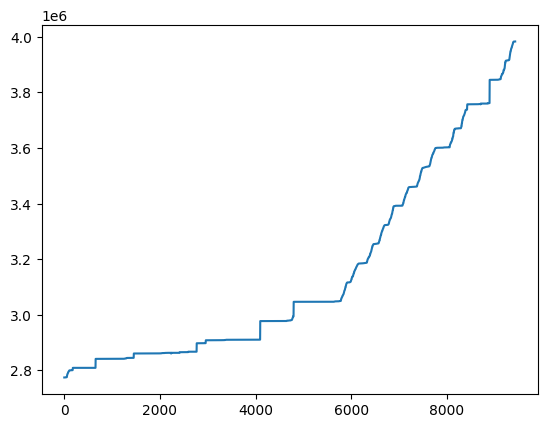

In [69]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [70]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


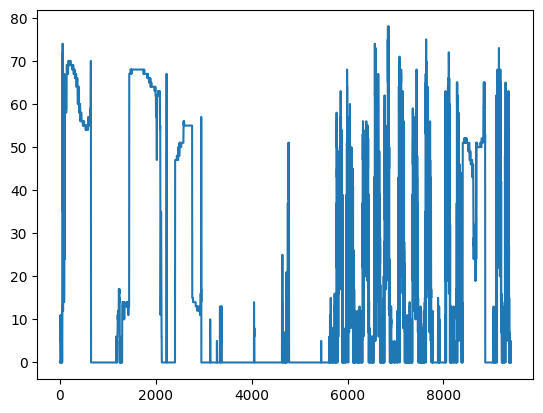

In [71]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historical events

In [72]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 0b10000000)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

print(satellite_connection_indicator)
unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 128, 0, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

Satellites Number

In [73]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 9427 entries, 3 to 92346
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         9427 non-null   str  
 1   Message                         9427 non-null   str  
 2   Status                          9427 non-null   str  
 3   Headers                         9427 non-null   str  
 4   Satellites                      9427 non-null   int64
 5   Satellite_connection_indicator  9427 non-null   int64
 6   Raw data                        9427 non-null   str  
 7   date                            9427 non-null   str  
dtypes: int64(2), str(6)
memory usage: 662.8 KB
0 -> 2026-09-25 05:09:20.445 -> 0 -> 0x252514005940550869487060177069003C38402D0000293E000000000700644100000000000003FFFFFFFFFFFF16D5002A55D11826092505053682CC000A02CD82CBC5A9010B0000000003671236FFFFFF000012FFFFFFFFFF
0 -> 2026-09-25 05:09:19.044 -> 0 -> 0x25251300591643

Coordinates

In [74]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8])

<class 'pandas.DataFrame'>
Index: 9427 entries, 3 to 92346
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            9427 non-null   str    
 1   Message            9427 non-null   str    
 2   Status             9427 non-null   str    
 3   Headers            9427 non-null   str    
 4   Latitude           9427 non-null   str    
 5   Latitude_decoded   9427 non-null   float64
 6   Longitude          9427 non-null   str    
 7   Longitude_decoded  9427 non-null   float64
 8   Raw data           9427 non-null   str    
 9   Date               9427 non-null   str    
 10  Speed              9427 non-null   int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 883.8 KB
None
260925050536 -> C5A9010B -> 2.497221668254806e-32 -> 02CD82CB -> -17144324.0 0x252514005940550869487060177069003C38402D0000293E000000000700644100000000000003FFFFFFFFFFFF16D5002A55D11826092505053682CC000A02CD82CBC5A9010B

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [75]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\in_outs_V4C-934.csv')

<class 'pandas.DataFrame'>
Index: 9427 entries, 2 to 92345
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  9427 non-null   str  
 1   Message  9427 non-null   str  
 2   Status   9427 non-null   str  
 3   Headers  9427 non-null   str  
dtypes: str(4)
memory usage: 368.2 KB


Ignition

In [76]:
in_outs_df.info()

for i in range(0,in_outs_df.shape[0]):
    length=len(in_outs_df.iloc[i,0])
    if length>16:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])
    else:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])

<class 'pandas.DataFrame'>
Index: 9400 entries, 3517 to 3516
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  9400 non-null   str  
 1   date         9400 non-null   str  
 2   raw data     9400 non-null   str  
dtypes: str(3)
memory usage: 293.8 KB
Ignition On 0b100000100000000
Ignition Off 0b0
Ignition Off 0b0
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignit

Door detection

In [77]:
x='0b0011000000000000' # for 16 bits, len=18

print(len(x),(x[4:6]))

y='0b011000000000000'   # for 15 bits, len=17
print(len(y), (y[3:5]))


18 11
17 11


In [78]:
in_outs=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\in_outs_V4C-934.csv',sep=',')
in_outs.info()
for i in range(0,in_outs.shape[0]):
    aux=(in_outs.iloc[i,1])
    if len(aux)==18:
        aux_2=(in_outs.iloc[i,1][4:6])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)
    if len(aux)==17:
        aux_2=(in_outs.iloc[i,1][3:5])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)

<class 'pandas.DataFrame'>
RangeIndex: 9400 entries, 0 to 9399
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   9400 non-null   int64
 1   in and outs  9400 non-null   str  
 2   date         9400 non-null   int64
 3   raw data     9400 non-null   str  
dtypes: int64(2), str(2)
memory usage: 293.9 KB


Panic detection

In [79]:
unit_.info()

<class 'pandas.DataFrame'>
RangeIndex: 9400 entries, 0 to 9399
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  9400 non-null   str  
 1   date         9400 non-null   str  
 2   raw data     9400 non-null   str  
dtypes: str(3)
memory usage: 220.4 KB


In [80]:
for i in range(0,unit_.shape[0]):
    if unit_.iloc[i,2][92:94]=='42':
        print(unit_.iloc[i,2],unit_.iloc[i,1])

iButton

In [81]:
id_button_m=raw_data[raw_data['Headers'].str.contains('0x252523')]
device_id=[]
id_button_date=[]

for i in range(0,id_button_m.shape[0]):
    device_id.append(id_button_m.iloc[i,2][84:100])
    id_button_date.append(id_button_m.iloc[i,2][32:44])
    print(id_button_m.iloc[i,2][84:100],id_button_m.iloc[i,2][32:44])

id_button_m['date']=id_button_date
id_button_m['device_id']=device_id

yymmdd=[]

for i in range(0,id_button_m.shape[0]):
    yymmdd.append(id_button_m.iloc[i,2][32:38])

id_button_m['yymmdd']=yymmdd
id_button_m.info()

1500001EF5982301 260925065207
1500001EF5982301 260925065505
1500001EF5982301 260925065505
1500001EF5982301 260925065506
1500001EF5982301 260925065506
1500001EF5982301 260925065507
1500001EF5982301 260925065507
1500001EF5982301 260925065508
1500001EF5982301 260925065508
1500001EF5982301 260925065509
1500001EF5982301 260925065510
1500001EF5982301 260925065510
1500001EF5982301 260925065511
1500001EF5982301 260925065511
1500001EF5982301 260925065512
1500001EF5982301 260925065512
1500001EF5982301 260925065513
1500001EF5982301 260925065514
1500001EF5982301 260925065514
1500001EF5982301 260925065515
1500001EF5982301 260925065516
1500001EF5982301 260925065517
1500001EF5982301 260925065517
1500001EF5982301 260925065518
1500001EF5982301 260925065518
1500001EF5982301 260925065519
1500001EF5982301 260925065519
1500001EF5982301 260925065520
1500001EF5982301 260925065520
1500001EF5982301 260925065521
1500001EF5982301 260925065521
1500001EF5982301 260925065524
1500001EF5982301 260925065526
1500001EF5

In [82]:
id_button_m['yymmdd'].value_counts()

yymmdd
261001    42688
260926    22688
260925    17229
260928        1
Name: count, dtype: int64

log de conductores

In [83]:
log=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\Drivers Log Report_es.xlsx')
sn='V4C-934'
log_v4C_934=log[log['Unidad'].str.contains(sn)]
log_v4C_934

,Conductor,Unidad,Unnamed: 2,Entrada,Unnamed: 4,Dirección / Landmark,Unnamed: 6,Unnamed: 7,Unnamed: 8,Salida,Unnamed: 10,Dirección / Landmark.1


In [84]:
hl=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\hl_v4c934.xlsx')
hl['Eventos'].value_counts()

Eventos
iButton Conectado               43510
Conduciendo                      1978
Inmóvil - Detenido               1464
Estacionado                       873
Alerta de Inmovilidad             312
Desplazándose - Ign. apagada      280
Ignición Apagada                  191
Ignición Encendida                191
Entrada a Geocerca                174
Salida de Geocerca                162
Saliendo de Landmark              151
Entrando a Landmark               143
Fin de Inmovilidad                 81
Name: count, dtype: int64